# Notebook 1 : préparation et exploration des données


**PLAN**
1. Objectifs

2. Imports et chemins

3. Préparation des évaluations
   * 3.1 Inspection
   * 3.2 Contrôle de structure
   * 3.3 Agrégation
   * 3.4 Contrôles qualité

4. Construction du réseau de confiance
   * 4.1 Import
   * 4.2 Nettoyage
   * 4.3 Contrôles qualité

5. Synchronisation des utilisateurs
   * 5.1 Recouvrement
   * 5.2 Réseau exploitable

6. Analyse exploratoire des évaluations
   * 6.1 Distribution des notes
   * 6.2 Activité utilisateurs
   * 6.3 Activité items
   * 6.4 Sparsité

7. Analyse exploratoire du réseau

8. Croisement activité / information sociale

9. Synthèse et conséquences pour la modélisation

10. Sauvegarde des données préparées

## 1. Objectif

Ce notebook a pour objectif de préparer et d’explorer les données Epinions utilisées pour le projet.

Il vise à :

* construire une table des évaluations à partir des fichiers de reviews ;
* préparer le réseau de confiance entre utilisateurs ;
* contrôler la qualité et la cohérence des données ;
* analyser la distribution des évaluations et la sparsité des données ;
* étudier la structure du réseau de confiance ;
* analyser la disponibilité de l’information sociale en fonction de l’activité des utilisateurs.

Cette analyse exploratoire permettra d’orienter et de justifier les choix de modélisation réalisés dans la suite du projet.

## 2. Imports et chemins

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

In [2]:
# Chemins des données
DATA_DIR = Path("../data")
RAW_DIR = DATA_DIR / "raw"
PROCESSED_DIR = DATA_DIR / "processed"

REVIEWS_DIR = RAW_DIR / "reviews"
TRUST_FILE = RAW_DIR / "userTrust.csv"

# Création du dossier des données préparées s'il n'existe pas
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

In [3]:
#contrôles
print("Dossier reviews :", REVIEWS_DIR.exists())
print("Fichier trust    :", TRUST_FILE.exists())

Dossier reviews : True
Fichier trust    : True


In [4]:
review_files = list(REVIEWS_DIR.glob("*_reviews.csv"))

print(f"Nombre de fichiers de reviews : {len(review_files):,}")

Nombre de fichiers de reviews : 163,539


## 3. Construction de la table des évaluations

### 3.1 Inspection d'un fichier

In [5]:
sample_file = review_files[0]

print("Fichier :", sample_file.name)

Fichier : beaner_reviews.csv


In [6]:
sample_reviews = pd.read_csv(
    sample_file,
    header=None
)

sample_reviews.head()

,0,1,2,3,4,5,6,7,8,9
0,Jan 25 '00,Flowers For Anyone,/srvc-review-64DC-89CA46-388E888E-bd3,1-800-FLOWERS.com,/webs-Web_Services-All-Merchants-1_800_FLOWERS...,Online Stores & Services,/webs-Web_Services-All,Online Stores & Services,4.0,Somewhat Helpful
1,Jan 25 '00,It's OK For a Day,/review/trvl-Ski_Resorts-United_States-Califor...,Mountain High,/reviews/trvl-Ski_Resorts-United_States-Califo...,Ski Resorts,/Ski_Resorts,Hotels & Travel,2.0,Helpful
2,Jan 23 '00,You've got to watch Millionaire,/review/tele-TV_Channels-All-ABC/elec-review-2...,ABC,/reviews/tele-TV_Channels-All-ABC,TV Channels,/TV_Channels,Media,5.0,Very Helpful
3,Jan 23 '00,Get all the gossip you need,/review/mags-People_Magazine/mags-review-5C55-...,People Magazine,/reviews/mags-People_Magazine,Magazine Subscriptions,/Magazine_Subscriptions,Magazines & Newspapers,5.0,Somewhat Helpful
4,Jan 23 '00,You've Got to Bust-A-Move,/review/game-Software-All-Playstation-Bust-A-M...,Bust-A-Move 99 for PlayStation 1,/reviews/game-Software-All-Playstation-Bust-A-...,PlayStation 1 Games,/PlayStation_1_Games,Games,3.0,Very Helpful


In [7]:
print("Dimensions :", sample_reviews.shape)

Dimensions : (19, 10)


In [8]:
sample_reviews.info()

<class 'pandas.DataFrame'>
RangeIndex: 19 entries, 0 to 18
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0       19 non-null     str    
 1   1       19 non-null     str    
 2   2       19 non-null     str    
 3   3       19 non-null     str    
 4   4       19 non-null     str    
 5   5       19 non-null     str    
 6   6       19 non-null     str    
 7   7       19 non-null     str    
 8   8       19 non-null     float64
 9   9       19 non-null     str    
dtypes: float64(1), str(9)
memory usage: 5.7 KB


In [9]:
sample_reviews.isna().sum()

0    0
1    0
2    0
3    0
4    0
5    0
6    0
7    0
8    0
9    0
dtype: int64

In [10]:
#Renommage des colonnes
columns = [
    "review_date",
    "review_title",
    "review_url",
    "item_name",
    "item_path",
    "subcategory",
    "subcategory_url",
    "category",
    "rating",
    "helpfulness"
]

sample_reviews.columns = columns

sample_reviews.head()

,review_date,review_title,review_url,item_name,item_path,subcategory,subcategory_url,category,rating,helpfulness
0,Jan 25 '00,Flowers For Anyone,/srvc-review-64DC-89CA46-388E888E-bd3,1-800-FLOWERS.com,/webs-Web_Services-All-Merchants-1_800_FLOWERS...,Online Stores & Services,/webs-Web_Services-All,Online Stores & Services,4.0,Somewhat Helpful
1,Jan 25 '00,It's OK For a Day,/review/trvl-Ski_Resorts-United_States-Califor...,Mountain High,/reviews/trvl-Ski_Resorts-United_States-Califo...,Ski Resorts,/Ski_Resorts,Hotels & Travel,2.0,Helpful
2,Jan 23 '00,You've got to watch Millionaire,/review/tele-TV_Channels-All-ABC/elec-review-2...,ABC,/reviews/tele-TV_Channels-All-ABC,TV Channels,/TV_Channels,Media,5.0,Very Helpful
3,Jan 23 '00,Get all the gossip you need,/review/mags-People_Magazine/mags-review-5C55-...,People Magazine,/reviews/mags-People_Magazine,Magazine Subscriptions,/Magazine_Subscriptions,Magazines & Newspapers,5.0,Somewhat Helpful
4,Jan 23 '00,You've Got to Bust-A-Move,/review/game-Software-All-Playstation-Bust-A-M...,Bust-A-Move 99 for PlayStation 1,/reviews/game-Software-All-Playstation-Bust-A-...,PlayStation 1 Games,/PlayStation_1_Games,Games,3.0,Very Helpful


In [11]:
#retrouver le nom de l'utilisateur
user_id = sample_file.stem.replace("_reviews", "")

print("Utilisateur :", user_id)

Utilisateur : beaner


In [12]:
# ajout de la colonne user_id
sample_reviews["user_id"] = user_id

In [13]:
sample_reviews.head()

,review_date,review_title,review_url,item_name,item_path,subcategory,subcategory_url,category,rating,helpfulness,user_id
0,Jan 25 '00,Flowers For Anyone,/srvc-review-64DC-89CA46-388E888E-bd3,1-800-FLOWERS.com,/webs-Web_Services-All-Merchants-1_800_FLOWERS...,Online Stores & Services,/webs-Web_Services-All,Online Stores & Services,4.0,Somewhat Helpful,beaner
1,Jan 25 '00,It's OK For a Day,/review/trvl-Ski_Resorts-United_States-Califor...,Mountain High,/reviews/trvl-Ski_Resorts-United_States-Califo...,Ski Resorts,/Ski_Resorts,Hotels & Travel,2.0,Helpful,beaner
2,Jan 23 '00,You've got to watch Millionaire,/review/tele-TV_Channels-All-ABC/elec-review-2...,ABC,/reviews/tele-TV_Channels-All-ABC,TV Channels,/TV_Channels,Media,5.0,Very Helpful,beaner
3,Jan 23 '00,Get all the gossip you need,/review/mags-People_Magazine/mags-review-5C55-...,People Magazine,/reviews/mags-People_Magazine,Magazine Subscriptions,/Magazine_Subscriptions,Magazines & Newspapers,5.0,Somewhat Helpful,beaner
4,Jan 23 '00,You've Got to Bust-A-Move,/review/game-Software-All-Playstation-Bust-A-M...,Bust-A-Move 99 for PlayStation 1,/reviews/game-Software-All-Playstation-Bust-A-...,PlayStation 1 Games,/PlayStation_1_Games,Games,3.0,Very Helpful,beaner


In [14]:
# Sélection des colonnes utiles pour le projet
sample_ratings = sample_reviews[
    ["user_id","item_name", "item_path", "rating", "review_date"]
].copy()

sample_ratings.head()

,user_id,item_name,item_path,rating,review_date
0,beaner,1-800-FLOWERS.com,/webs-Web_Services-All-Merchants-1_800_FLOWERS...,4.0,Jan 25 '00
1,beaner,Mountain High,/reviews/trvl-Ski_Resorts-United_States-Califo...,2.0,Jan 25 '00
2,beaner,ABC,/reviews/tele-TV_Channels-All-ABC,5.0,Jan 23 '00
3,beaner,People Magazine,/reviews/mags-People_Magazine,5.0,Jan 23 '00
4,beaner,Bust-A-Move 99 for PlayStation 1,/reviews/game-Software-All-Playstation-Bust-A-...,3.0,Jan 23 '00


### 3.2 Vérification de la structure des fichiers

Avant d'agréger l'ensemble des fichiers, leur structure est contrôlée sur un échantillon aléatoire reproductible.

In [15]:
# création de l'échantillon de 1000 fichiers
rng = np.random.default_rng(42)

sample_files = rng.choice(
    review_files,
    size=1000,
    replace=False
)


In [16]:
checks = []

for file in sample_files:
    
    if file.stat().st_size == 0:
        checks.append({
            "file": file.name,
            "status": "empty",
            "n_rows": 0,
            "n_columns": 0,
            "missing_item_path": np.nan,
            "missing_rating": np.nan
        })
        continue

    try:
        df = pd.read_csv(file, header=None)

        checks.append({
            "file": file.name,
            "status": "ok",
            "n_rows": len(df),
            "n_columns": df.shape[1],
            "missing_item_path": df[4].isna().sum(),
            "missing_rating": df[8].isna().sum()
        })

    except Exception:
        checks.append({
            "file": file.name,
            "status": "error",
            "n_rows": np.nan,
            "n_columns": np.nan,
            "missing_item_id": np.nan,
            "missing_rating": np.nan
        })

checks = pd.DataFrame(checks)

In [17]:
checks.head()

,file,status,n_rows,n_columns,missing_item_path,missing_rating
0,never2forget_reviews.csv,empty,0,0,NaN,NaN
1,justsayingso_reviews.csv,ok,1,10,0.0,0.0
2,Babyof8_reviews.csv,ok,32,10,0.0,0.0
3,allcorn_reviews.csv,ok,1,10,0.0,0.0
4,komernik_reviews.csv,ok,6,10,0.0,0.0


In [18]:
checks["status"].value_counts()

status
ok       781
empty    219
Name: count, dtype: int64

Sur l’échantillon de 1 000 fichiers, 219 sont vides. Les fichiers non vides sont analysés séparément afin de vérifier l’homogénéité de leur structure avant l’agrégation complète.

In [19]:
checks_ok = checks[checks["status"] == "ok"]

checks_ok["n_columns"].value_counts().sort_index()

n_columns
10    781
Name: count, dtype: int64

In [20]:
print("Item_path manquants :", checks_ok["missing_item_path"].sum())
print("Ratings manquants :", checks_ok["missing_rating"].sum())

Item_path manquants : 74.0
Ratings manquants : 0.0


In [21]:
# Vérification des valeurs ratings
ratings_sample = []

for file in sample_files:
    if file.stat().st_size == 0:
        continue

    df = pd.read_csv(file, header=None)

    ratings_sample.extend(df[8].dropna().tolist())

pd.Series(ratings_sample).value_counts().sort_index()

1.0     633
2.0     653
3.0    1046
4.0    2622
5.0    3270
Name: count, dtype: int64

In [22]:
# Contrôle des observations sans item_path
missing_items = []

for file in sample_files:
    if file.stat().st_size == 0:
        continue

    df = pd.read_csv(file, header=None)

    missing = df[df[4].isna()].copy()

    if not missing.empty:
        missing["user_id"] = file.stem.replace("_reviews", "")
        missing_items.append(missing)

missing_items = pd.concat(missing_items, ignore_index=True)

missing_items[[3, 4, 5, 6, 7, 8, "user_id"]].head()

,3,4,5,6,7,8,user_id
0,NaN,NaN,NaN,NaN,<font color=666666><i>Category information una...,4.0,louvre99
1,NaN,NaN,NaN,NaN,<font color=666666><i>Category information una...,1.0,sfoguyone
2,NaN,NaN,NaN,NaN,<font color=666666><i>Category information una...,2.0,HonestyIsKey
3,NaN,NaN,NaN,NaN,<font color=666666><i>Category information una...,4.0,tanta07
4,NaN,NaN,NaN,NaN,<font color=666666><i>Category information una...,4.0,CJCraft


#### Conclusion

Les fichiers non vides de l'échantillon présentent une structure homogène de 10 colonnes et aucune note manquante. Les notes observées sont comprises entre 1 et 5.

Certains fichiers sont vides et certaines évaluations ne disposent pas de nom ou de chemin d'item. Ces observations ne permettent pas de construire un couple utilisateur-item et seront donc exclues lors de l'agrégation des données.

Ces contrôles permettent de procéder à la construction de la table complète des évaluations.

### 3.3 Construction de la table des évaluations

Les fichiers de reviews sont agrégés afin de construire une table unique contenant les utilisateurs, les items, les notes attribuées et les dates des évaluations.

Les fichiers vides et les évaluations sans chemin de fiche Epinions (item_path) sont écartés.

In [23]:
ratings_list = []

n_empty_files = 0
n_read_errors = 0
n_raw_reviews = 0
n_missing_item = 0

for file in review_files:

    # Fichiers sans review
    if file.stat().st_size == 0:
        n_empty_files += 1
        continue

    try:
        df = pd.read_csv(
            file,
            header=None,
            usecols=[0, 3, 4, 5, 7, 8],
            names=[
                "review_date",
                "item_name",
                "item_path",
                "subcategory",
                "category",
                "rating"
            ]
        )

        n_raw_reviews += len(df)

        # Nombre d'évaluations sans item identifiable
        n_missing_item += df["item_path"].isna().sum()

        # Suppression des évaluations sans item identifiable
        df = df.dropna(subset=["item_path"])

        # L'identifiant utilisateur est extrait du nom du fichier
        df["user_id"] = file.stem.replace("_reviews", "")

        ratings_list.append(
            df[
                [
                    "user_id",
                    "item_path",
                    "item_name",
                    "category",
                    "subcategory",
                    "rating",
                    "review_date"
                ]
            ]
        )

    except Exception as e:
        n_read_errors += 1
        print(f"Erreur avec {file.name} : {e}")


In [24]:
ratings = pd.concat(
    ratings_list,
    ignore_index=True
)

In [25]:
print(f"Fichiers vides         : {n_empty_files:,}")
print(f"Erreurs de lecture     : {n_read_errors:,}")
print(f"Reviews brutes         : {n_raw_reviews:,}")
print(f"Item_path manquants    : {n_missing_item:,}")
print(f"Évaluations conservées : {len(ratings):,}")

ratings.head()

Fichiers vides         : 34,408
Erreurs de lecture     : 0
Reviews brutes         : 1,266,012
Item_path manquants    : 13,278
Évaluations conservées : 1,252,734


,user_id,item_path,item_name,category,subcategory,rating,review_date
0,beaner,/webs-Web_Services-All-Merchants-1_800_FLOWERS...,1-800-FLOWERS.com,Online Stores & Services,Online Stores & Services,4.0,Jan 25 '00
1,beaner,/reviews/trvl-Ski_Resorts-United_States-Califo...,Mountain High,Hotels & Travel,Ski Resorts,2.0,Jan 25 '00
2,beaner,/reviews/tele-TV_Channels-All-ABC,ABC,Media,TV Channels,5.0,Jan 23 '00
3,beaner,/reviews/mags-People_Magazine,People Magazine,Magazines & Newspapers,Magazine Subscriptions,5.0,Jan 23 '00
4,beaner,/reviews/game-Software-All-Playstation-Bust-A-...,Bust-A-Move 99 for PlayStation 1,Games,PlayStation 1 Games,3.0,Jan 23 '00


Après agrégation, 1 252 734 évaluations exploitables sont conservées.  
13 278 reviews, soit environ 1,05 % des observations, ont été exclues car aucun chemin d'item n'était disponible.

### 3.4 Contrôles qualité

#### 3.4.1 Types et valeurs manquantes

In [26]:
ratings["review_date"] = pd.to_datetime(
    ratings["review_date"],
    format="%b %d '%y",
    errors="coerce"
)

In [27]:
text_cols = [
    "user_id",
    "item_name",
    "item_path",
    "subcategory",
    "category"
]

for col in text_cols:
    ratings[col] = ratings[col].astype("string")

In [28]:
ratings.dtypes

user_id                string
item_path              string
item_name              string
category               string
subcategory            string
rating                float64
review_date    datetime64[us]
dtype: object

In [29]:
#valeurs manquantes et type
ratings.info()
ratings.isna().sum()

<class 'pandas.DataFrame'>
RangeIndex: 1252734 entries, 0 to 1252733
Data columns (total 7 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   user_id      1252734 non-null  string        
 1   item_path    1252734 non-null  string        
 2   item_name    1252732 non-null  string        
 3   category     1252734 non-null  string        
 4   subcategory  1252734 non-null  string        
 5   rating       1252734 non-null  float64       
 6   review_date  1252734 non-null  datetime64[us]
dtypes: datetime64[us](1), float64(1), string(5)
memory usage: 193.6 MB


user_id        0
item_path      0
item_name      2
category       0
subcategory    0
rating         0
review_date    0
dtype: int64

In [30]:
ratings[ratings["item_name"].isna()]

,user_id,item_path,item_name,category,subcategory,rating,review_date
754018,margomargo,/book_mu-3833010,<NA>,Books,Books,4.0,2000-11-02
1016560,jejensen,/book_mu-2284835,<NA>,Books,Books,5.0,2000-11-12


Deux observations présentent un nom d'item manquant, mais disposent d'un `item_path` valide.

Le jeu de données ne fournit pas d’identifiant numérique explicite pour les items. Le chemin de la fiche Epinions `item_path` est utilisé comme clé de référence, le nom de l’item étant conservé uniquement à des fins descriptives.

#### 3.4.2 Contrôle des notes et des dates

In [31]:
ratings["rating"].value_counts().sort_index()

rating
1.0     94927
2.0     92495
3.0    148714
4.0    372783
5.0    543815
Name: count, dtype: int64

In [32]:
print("Date minimale :", ratings["review_date"].min())
print("Date maximale :", ratings["review_date"].max())
print("Dates manquantes :", ratings["review_date"].isna().sum())

Date minimale : 1999-07-05 00:00:00
Date maximale : 2011-05-09 00:00:00
Dates manquantes : 0


#### 3.4.3 Contrôle des doublons

In [33]:
exact_duplicates = ratings.duplicated().sum()

duplicate_pairs = ratings.duplicated(
    subset=["user_id", "item_path"]
).sum()

print(f"Doublons exacts : {exact_duplicates:,}")
print(f"Couples utilisateur-item répétés : {duplicate_pairs:,}")

Doublons exacts : 2,017
Couples utilisateur-item répétés : 13,105


In [34]:
exact_duplicate_rows = ratings[
    ratings.duplicated(keep=False)
].sort_values(
    ["user_id", "item_path", "review_date"]
)

exact_duplicate_rows.head(20)

,user_id,item_path,item_name,category,subcategory,rating,review_date
603547,05fubu,/archive-auto_prod,Archived Autos & Motorsports Reviews,,Archived Reviews,5.0,2000-01-12
603549,05fubu,/archive-auto_prod,Archived Autos & Motorsports Reviews,,Archived Reviews,5.0,2000-01-12
399291,1Goodguy,/reviews/sprt-Venues-Cooperstown_Hall_of_Fame,Cooperstown Hall of Fame,Sports & Outdoors,Stadiums and Arenas,5.0,2000-04-01
399292,1Goodguy,/reviews/sprt-Venues-Cooperstown_Hall_of_Fame,Cooperstown Hall of Fame,Sports & Outdoors,Stadiums and Arenas,5.0,2000-04-01
226777,1eyedoc,/reviews/educ-Colleges_and_Universities-All-Un...,University of California-San Diego,Education,Colleges and Universities,5.0,2000-01-19
226778,1eyedoc,/reviews/educ-Colleges_and_Universities-All-Un...,University of California-San Diego,Education,Colleges and Universities,5.0,2000-01-19
226779,1eyedoc,/reviews/educ-Colleges_and_Universities-All-Un...,University of California-San Diego,Education,Colleges and Universities,5.0,2000-01-19
215419,2manykids,/reviews/park-Parks-All-WA-Olympic_National_Park,Olympic National Park,Hotels & Travel,Parks,5.0,2000-07-18
215420,2manykids,/reviews/park-Parks-All-WA-Olympic_National_Park,Olympic National Park,Hotels & Travel,Parks,5.0,2000-07-18
215448,2manykids,/reviews/trvl-Dest-United_States-Arkansas-Litt...,Little Rock,Hotels & Travel,Destinations,5.0,2000-05-14


In [35]:
ratings = ratings.drop_duplicates()

In [36]:
pair_counts = (
    ratings
    .groupby(["user_id", "item_path"])
    .size()
)

repeated_pairs = pair_counts[pair_counts > 1]

print(f"Couples encore répétés : {len(repeated_pairs):,}")

Couples encore répétés : 7,707


In [37]:
n_ratings_per_pair = (
    ratings
    .groupby(["user_id", "item_path"])["rating"]
    .nunique()
)

different_ratings = n_ratings_per_pair[n_ratings_per_pair > 1]

print(
    f"Couples avec plusieurs notes différentes : "
    f"{len(different_ratings):,}"
)

Couples avec plusieurs notes différentes : 4,027


In [38]:
example_pairs = different_ratings.head(10).index

examples = pd.concat([
    ratings[
        (ratings["user_id"] == user) &
        (ratings["item_path"] == item)
    ]
    for user, item in example_pairs
])

examples[
    ["user_id", "item_name", "item_path", "rating", "review_date"]
].sort_values(
    ["user_id", "item_path", "review_date"]
)

,user_id,item_name,item_path,rating,review_date
1009414,.475Linebaugh,Archived Outdoors Reviews,/archive-otdr_prod,4.0,2000-12-26
1009412,.475Linebaugh,Archived Outdoors Reviews,/archive-otdr_prod,5.0,2000-12-29
1009410,.475Linebaugh,Archived Outdoors Reviews,/archive-otdr_prod,4.0,2000-12-31
1014172,00Shoe,MACHINA/The Machines of God by Smashing Pumpkins,/reviews/musc_mu-331695,5.0,2000-04-15
1014167,00Shoe,MACHINA/The Machines of God by Smashing Pumpkins,/reviews/musc_mu-331695,4.0,2000-04-28
866953,12zeros,MTV,/reviews/tele-TV_Channels-All-MTV,2.0,2000-01-25
866954,12zeros,MTV,/reviews/tele-TV_Channels-All-MTV,5.0,2000-01-25
1084804,2-BITS,Harveys Lake Tahoe,/Harveys_Lake_Tahoe_NV_89449_United_States,5.0,2000-05-10
1084808,2-BITS,Harveys Lake Tahoe,/Harveys_Lake_Tahoe_NV_89449_United_States,4.0,2000-05-10
1084812,2-BITS,Copacabana Palace,/reviews/lodg-Accommodations-North_America-Cas...,2.0,2000-05-07


Après suppression des 2 017 doublons exacts, il reste :

* 7 707 couples utilisateur–item répétés ;
* dont 4 027 couples avec des notes différentes.

Pour la factorisation matricielle, il nous faut une seule valeur par couple utilisateur-item. On ne peut donc pas laisser ces répétitions telles quelles.

In [39]:
same_day_counts = (
    ratings
    .groupby(["user_id", "item_path", "review_date"])
    .size()
)

same_day_duplicates = same_day_counts[same_day_counts > 1]

print(
    f"Couples utilisateur-item-date répétés : "
    f"{len(same_day_duplicates):,}"
)

Couples utilisateur-item-date répétés : 1,034


Pour régler le problème des doublons sur des jours différents, on choisit de garder l’évaluation la plus récente, car elle représente l’état le plus récent de l’opinion de l’utilisateur.

In [40]:
# Date la plus récente pour chaque couple utilisateur-item
last_dates = (
    ratings
    .groupby(["user_id", "item_path"])["review_date"]
    .transform("max")
)

# Évaluations correspondant à la dernière date
last_ratings = ratings[
    ratings["review_date"] == last_dates
].copy()

In [41]:
# Nombre de notes différentes à la même date
n_last_ratings = (
    last_ratings
    .groupby(["user_id", "item_path"])["rating"]
    .nunique()
)

ambiguous_last = n_last_ratings[n_last_ratings > 1]

print(
    f"Couples ambigus à la même date : "
    f"{len(ambiguous_last):,}"
)

Couples ambigus à la même date : 683


Le nombre d'évaluations multiple le même jour étant extrêmement faible par rapport aux plus de 1,25 million d'évaluations, on décide de supprimer les couples user-item concernés.

In [42]:
ambiguous_pairs = set(ambiguous_last.index)

mask_ambiguous = pd.MultiIndex.from_frame(
    last_ratings[["user_id", "item_path"]]
).isin(ambiguous_pairs)

ratings_clean = last_ratings[
    ~mask_ambiguous
].copy()

In [43]:
ratings_clean = (
    ratings_clean
    .drop_duplicates(
        subset=["user_id", "item_path"],
        keep="first"
    )
    .reset_index(drop=True)
)

In [44]:
print(
    "Couples utilisateur-item encore répétés :",
    ratings_clean.duplicated(
        subset=["user_id", "item_path"]
    ).sum()
)

Couples utilisateur-item encore répétés : 0


In [45]:
print(f"Évaluations finales : {len(ratings_clean):,}")
print(f"Utilisateurs        : {ratings_clean['user_id'].nunique():,}")
print(f"Items               : {ratings_clean['item_path'].nunique():,}")

Évaluations finales : 1,238,946
Utilisateurs        : 128,962
Items               : 346,658


In [46]:
ratings = ratings_clean

##### Conclusion

Plusieurs évaluations peuvent être associées à un même couple utilisateur-item. 
Après suppression des doublons exacts, l'évaluation correspondant à la date la plus récente est retenue.

Lorsque plusieurs notes différentes sont présentes à cette dernière date, aucun ordre temporel ne permet de les départager. Les 683 couples concernés sont donc exclus plutôt que d'imputer ou de choisir arbitrairement une note.

## 4. Construction du réseau de confiance

### 4.1 Import

Le fichier `userTrust.csv` contient les relations de confiance déclarées entre utilisateurs. Une relation orientée `source_user → target_user` indique que l'utilisateur source fait confiance à l'utilisateur cible.

In [47]:
TRUST_FILE = Path("../data/raw/userTrust.csv")

trust_raw = pd.read_csv(
    TRUST_FILE,
    header=None
)

trust_raw.head()

,0,1,2
0,jo.com,teamfreak16,Mar 24 '11
1,jo.com,critic64,Mar 07 '11
2,jo.com,glen22,Feb 27 '11
3,jo.com,pestyside,Feb 12 '11
4,jo.com,imagine_stars,Jan 17 '11


In [48]:
trust_raw.shape

(582613, 3)

In [49]:
trust_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 582613 entries, 0 to 582612
Data columns (total 3 columns):
 #   Column  Non-Null Count   Dtype
---  ------  --------------   -----
 0   0       582593 non-null  str  
 1   1       582407 non-null  str  
 2   2       582613 non-null  str  
dtypes: str(3)
memory usage: 25.7 MB


In [50]:
trust_raw.columns = [
    "source_user",
    "target_user",
    "trust_date"
]

trust_raw.head()

,source_user,target_user,trust_date
0,jo.com,teamfreak16,Mar 24 '11
1,jo.com,critic64,Mar 07 '11
2,jo.com,glen22,Feb 27 '11
3,jo.com,pestyside,Feb 12 '11
4,jo.com,imagine_stars,Jan 17 '11


In [51]:
trust_raw.isna().sum()

source_user     20
target_user    206
trust_date       0
dtype: int64

In [52]:
print(f"Relations de confiance : {len(trust_raw):,}")
print(f"Utilisateurs sources   : {trust_raw['source_user'].nunique():,}")
print(f"Utilisateurs cibles    : {trust_raw['target_user'].nunique():,}")

Relations de confiance : 582,613
Utilisateurs sources   : 75,157
Utilisateurs cibles    : 61,239


In [53]:
trust_raw["trust_date"].head()

0    Mar 24 '11
1    Mar 07 '11
2    Feb 27 '11
3    Feb 12 '11
4    Jan 17 '11
Name: trust_date, dtype: str

La date de création des relations ne sera pas conservée, l’étude exploitant uniquement l’existence et l’orientation des relations de confiance.

In [54]:
trust = trust_raw[
    ["source_user", "target_user"]
].copy()

### 4.2 Nettoyage

#### 4.2.1 Relations incomplètes

Une relation sociale n’est exploitable que si ses deux extrémités sont connues. Il faut donc supprimer les lignes où source_user ou target_user est absent.

In [55]:
missing_users = trust[
    trust[["source_user", "target_user"]]
    .isna()
    .any(axis=1)
]

print(f"Relations incomplètes : {len(missing_users):,}")

Relations incomplètes : 226


In [56]:
missing_users.head()

,source_user,target_user
5278,BrianKoller,NaN
16059,charles,NaN
24870,calwaone,NaN
42833,scott29,NaN
44044,Andrew_Hicks,NaN


In [57]:
trust = trust.dropna(
    subset=["source_user", "target_user"]
).copy()

#### 4.2.2 Doublons

In [58]:
print(
    "Doublons exacts :",
    trust.duplicated().sum()
)

Doublons exacts : 1225


In [59]:
duplicate_edges = trust.duplicated(
    subset=["source_user", "target_user"]
).sum()

print(
    f"Relations source-cible répétées : {duplicate_edges:,}"
)

Relations source-cible répétées : 1,225


Il n’existe aucun couple (source_user, target_user) répété avec une date différente. Toutes les répétitions de relations sont simplement des lignes dupliquées à l’identique.

On peut donc les supprimer.

In [60]:
trust = trust.drop_duplicates().reset_index(drop=True)

In [61]:
print(f"Doublons exacts : {trust.duplicated().sum():,}")

print(
    "Relations source-cible répétées :",
    trust.duplicated(
        subset=["source_user", "target_user"]
    ).sum()
)

Doublons exacts : 0
Relations source-cible répétées : 0


#### 4.2.3 Auto-relations

In [62]:
self_links = (
    trust["source_user"] == trust["target_user"]
).sum()

print(f"Auto-relations : {self_links:,}")

Auto-relations : 636


Une autorelation n’apporte aucune information sur le voisinage social de l’utilisateur. Pour notre future approche sociale, on cherche justement à exploiter l’information provenant d’autres utilisateurs.

In [63]:
trust = trust[
    trust["source_user"] != trust["target_user"]
].copy()

trust.reset_index(drop=True, inplace=True)

### 4.3 Contrôles qualité

Après nettoyage, la cohérence du réseau de confiance est vérifiée avant son utilisation pour l'analyse et la modélisation.

In [64]:
print("Valeurs manquantes :")
print(trust.isna().sum())

print(
    "\nRelations dupliquées :",
    trust.duplicated(
        subset=["source_user", "target_user"]
    ).sum()
)

print(
    "Auto-relations :",
    (trust["source_user"] == trust["target_user"]).sum()
)

social_users = set(trust["source_user"]) | set(trust["target_user"])

print(f"\nRelations de confiance : {len(trust):,}")
print(f"Utilisateurs sources   : {trust['source_user'].nunique():,}")
print(f"Utilisateurs cibles    : {trust['target_user'].nunique():,}")
print(f"Utilisateurs du réseau : {len(social_users):,}")

Valeurs manquantes :
source_user    0
target_user    0
dtype: int64

Relations dupliquées : 0
Auto-relations : 0

Relations de confiance : 580,526
Utilisateurs sources   : 74,888
Utilisateurs cibles    : 60,906
Utilisateurs du réseau : 98,654


## 5. Synchronisation des utilisateurs

Les données d'évaluation et le réseau de confiance proviennent de fichiers distincts et peuvent contenir des ensembles d'utilisateurs différents.

Cette étape vise à mesurer leur recouvrement et à construire un jeu de données cohérent pour la comparaison des approches sociale et non sociale.

In [65]:
# Construction des deux ensembles d'utilisateurs
rating_users = set(ratings["user_id"])

social_users = (
    set(trust["source_user"])
    | set(trust["target_user"])
)

print(f"Utilisateurs avec évaluations : {len(rating_users):,}")
print(f"Utilisateurs du réseau social : {len(social_users):,}")

Utilisateurs avec évaluations : 128,962
Utilisateurs du réseau social : 98,654


In [66]:
# Intersection
common_users = rating_users & social_users

print(f"Utilisateurs communs : {len(common_users):,}")

Utilisateurs communs : 66,632


In [67]:
pct_rating_with_social = (
    100 * len(common_users) / len(rating_users)
)

pct_social_with_rating = (
    100 * len(common_users) / len(social_users)
)

print(
    f"Utilisateurs avec ratings présents dans le réseau : "
    f"{pct_rating_with_social:.2f} %"
)

print(
    f"Utilisateurs du réseau ayant des ratings : "
    f"{pct_social_with_rating:.2f} %"
)

Utilisateurs avec ratings présents dans le réseau : 51.67 %
Utilisateurs du réseau ayant des ratings : 67.54 %


Le recouvrement entre les deux sources est partiel : 66 632 utilisateurs sont présents à la fois dans les évaluations et dans le réseau de confiance, soit 51,67 % des utilisateurs ayant évalué au moins un item.

La présence dans les deux sources ne garantit toutefois pas qu'une relation sociale soit exploitable pour la recommandation : il faut également vérifier que les utilisateurs reliés disposent eux-mêmes d'évaluations.

In [68]:
trust_with_ratings = trust[
    trust["source_user"].isin(rating_users)
    & trust["target_user"].isin(rating_users)
].copy()

print(f"Relations sociales totales            : {len(trust):,}")
print(f"Relations entre utilisateurs avec notes : {len(trust_with_ratings):,}")
print(
    f"Part des relations conservées         : "
    f"{100 * len(trust_with_ratings) / len(trust):.2f} %"
)

Relations sociales totales            : 580,526
Relations entre utilisateurs avec notes : 509,872
Part des relations conservées         : 87.83 %


In [69]:
usable_social_users = (
    set(trust_with_ratings["source_user"])
    | set(trust_with_ratings["target_user"])
)

print(
    f"Utilisateurs impliqués dans au moins "
    f"une relation exploitable : {len(usable_social_users):,}"
)

print(
    f"Part des utilisateurs avec ratings : "
    f"{100 * len(usable_social_users) / len(rating_users):.2f} %"
)

Utilisateurs impliqués dans au moins une relation exploitable : 63,559
Part des utilisateurs avec ratings : 49.29 %


La majorité des relations de confiance restent exploitables après synchronisation : 509 872 relations (87,83 %) relient deux utilisateurs disposant d'évaluations.

Ces relations concernent 63 559 utilisateurs, soit 49,29 % des utilisateurs présents dans la table des évaluations. Le réseau social exploitable reste donc suffisamment important pour permettre la comparaison entre une approche classique et une approche intégrant l'information sociale.

## 6. Analyse exploratoire des évaluations

### 6.1 Distribution des notes

In [70]:
rating_counts = (
    ratings["rating"]
    .value_counts()
    .sort_index()
)

rating_pct = (
    ratings["rating"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
)

rating_distribution = pd.DataFrame({
    "effectif": rating_counts,
    "pourcentage": rating_pct
})

rating_distribution

,effectif,pourcentage
rating,,
1.0,93967,7.584431
2.0,91599,7.393300
3.0,147353,11.893416
4.0,368991,29.782654
5.0,537036,43.346199


In [71]:
print(f"Note moyenne  : {ratings['rating'].mean():.2f}")
print(f"Note médiane  : {ratings['rating'].median():.1f}")

Note moyenne  : 3.94
Note médiane  : 4.0


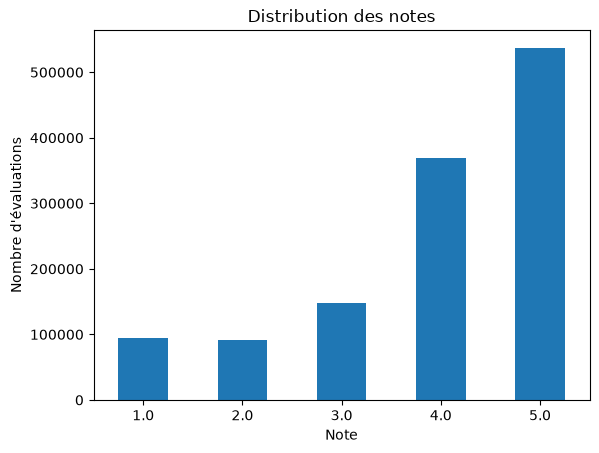

In [72]:
rating_counts.plot(kind="bar")

plt.xlabel("Note")
plt.ylabel("Nombre d'évaluations")
plt.title("Distribution des notes")
plt.xticks(rotation=0)
plt.show()

La distribution des notes est déséquilibrée en faveur des évaluations positives : 
les notes 4 et 5 représentent 73,13 % des observations. La note moyenne est de 
3,94 et la médiane de 4.

Ce déséquilibre devra être pris en compte dans l'interprétation des performances 
des modèles.

### 6.2 Activité des utilisateurs

Le nombre d'évaluations par utilisateur est étudié afin de caractériser la répartition de l'activité et d'identifier les utilisateurs disposant de peu d'historique.

#### 6.2.1 Nombre de ratings par utilisateur

In [73]:
ratings_per_user = (
    ratings
    .groupby("user_id")
    .size()
    .rename("n_ratings")
)

ratings_per_user.describe()

count    128962.000000
mean          9.607063
std          48.446886
min           1.000000
25%           1.000000
50%           2.000000
75%           7.000000
max        5356.000000
Name: n_ratings, dtype: float64

In [74]:
ratings_per_user.quantile(
    [0.90, 0.95, 0.99]
)

0.90     18.0
0.95     32.0
0.99    107.0
Name: n_ratings, dtype: float64

Ces résultats  montrent une distribution extrêmement asymétrique.

La moyenne de 9,61 ratings par utilisateur est assez trompeuse : l’utilisateur médian n’en a que 2. De plus, 25 % des utilisateurs n’ont qu’un seul rating, 75 % en ont au maximum 7, tandis que quelques utilisateurs extrêmement actifs atteignent jusqu’à 5 356 évaluations.

#### 6.2.2 Classes d'activité

In [75]:
user_activity = pd.cut(
    ratings_per_user,
    bins=[0, 5, 10, 20, 50, 100, np.inf],
    labels=["1–5", "6–10", "11–20", "21–50", "51–100", ">100"]
)

activity_counts = (
    user_activity
    .value_counts()
    .sort_index()
)

activity_table = pd.DataFrame({
    "utilisateurs": activity_counts,
    "pourcentage": (
        100 * activity_counts / len(ratings_per_user)
    )
})

activity_table

,utilisateurs,pourcentage
n_ratings,,
1–5,92079,71.400102
6–10,15096,11.705774
11–20,10892,8.445899
21–50,7340,5.691599
51–100,2167,1.680340
>100,1388,1.076286


 71,4 % des utilisateurs n’ont que 1 à 5 évaluations, et 83,1 % en ont au maximum 10.

#### 6.2.3 Visualisation

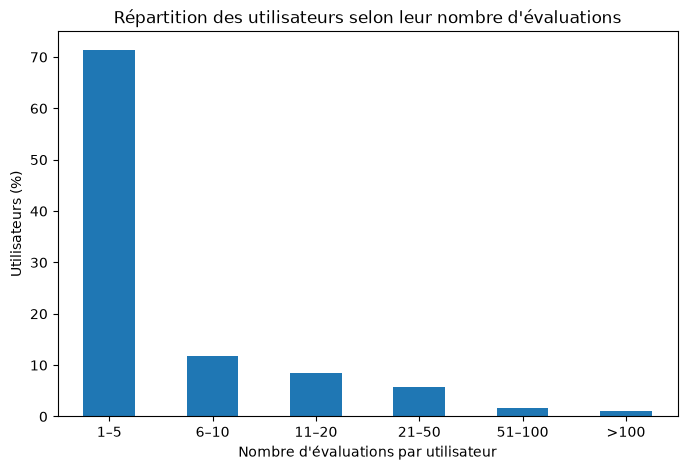

In [76]:
activity_table["pourcentage"].plot(
    kind="bar",
    figsize=(8, 5)
)

plt.xlabel("Nombre d'évaluations par utilisateur")
plt.ylabel("Utilisateurs (%)")
plt.title("Répartition des utilisateurs selon leur nombre d'évaluations")
plt.xticks(rotation=0)
plt.show()

L'activité des utilisateurs est très déséquilibrée. Le nombre médian d'évaluations par utilisateur est de 2, contre une moyenne de 9,61, et 71,4 % des utilisateurs n'ont publié que 1 à 5 évaluations.

Le jeu de données comporte donc une forte proportion d'utilisateurs disposant de peu d'historique. Cette caractéristique motive l'étude de l'apport de l'information sociale, notamment pour les utilisateurs peu actifs.

### 6.3 Activité des items

#### 6.3.1 Nombre d'évaluations par item

In [77]:
ratings_per_item = (
    ratings
    .groupby("item_path")
    .size()
    .rename("n_ratings")
)

ratings_per_item.describe()

count    346658.000000
mean          3.573972
std          15.381540
min           1.000000
25%           1.000000
50%           1.000000
75%           2.000000
max        2278.000000
Name: n_ratings, dtype: float64

In [78]:
ratings_per_item.quantile(
    [0.90, 0.95, 0.99]
)

0.90     6.0
0.95    11.0
0.99    41.0
Name: n_ratings, dtype: float64

#### 6.3.2 Répartition par niveau de popularité

In [79]:
item_activity = pd.cut(
    ratings_per_item,
    bins=[0, 5, 10, 20, 50, 100, np.inf],
    labels=["1–5", "6–10", "11–20", "21–50", "51–100", ">100"]
)

item_counts = (
    item_activity
    .value_counts()
    .sort_index()
)

item_activity_table = pd.DataFrame({
    "items": item_counts,
    "pourcentage": (
        100 * item_counts / len(ratings_per_item)
    )
})

item_activity_table

,items,pourcentage
n_ratings,,
1–5,310877,89.678300
6–10,17701,5.106185
11–20,9676,2.791224
21–50,5782,1.667926
51–100,1692,0.488089
>100,930,0.268276


#### 6.3.3 Visualisation

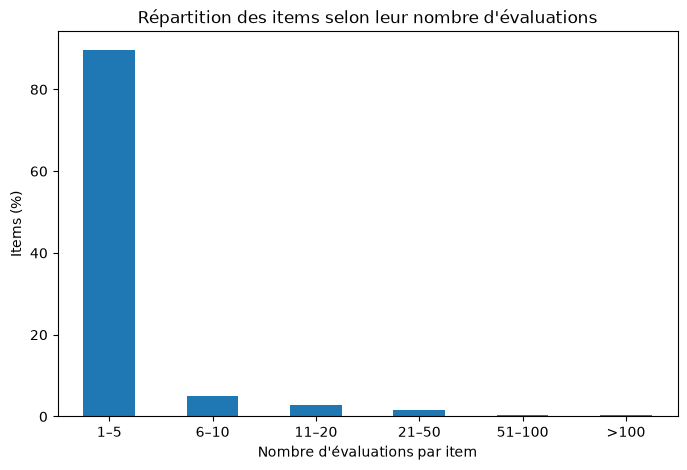

In [80]:
item_activity_table["pourcentage"].plot(
    kind="bar",
    figsize=(8, 5)
)

plt.xlabel("Nombre d'évaluations par item")
plt.ylabel("Items (%)")
plt.title("Répartition des items selon leur nombre d'évaluations")
plt.xticks(rotation=0)
plt.show()

L'activité des items est également très déséquilibrée. Le nombre médian d'évaluations par item est de 1 et 89,68 % des items disposent de seulement 1 à 5 évaluations.

La matrice utilisateur-item comporte donc une forte proportion d'utilisateurs et d'items faiblement renseignés, ce qui laisse présager une matrice très creuse.

### 6.4 Sparsité

La sparsité de la matrice utilisateur-item est évaluée afin de mesurer la proportion d'interactions effectivement observées parmi l'ensemble des couples utilisateur-item possibles.

In [81]:
n_users = ratings["user_id"].nunique()
n_items = ratings["item_path"].nunique()
n_ratings = len(ratings)

n_possible = n_users * n_items

density = n_ratings / n_possible
sparsity = 1 - density

print(f"Utilisateurs              : {n_users:,}")
print(f"Items                     : {n_items:,}")
print(f"Évaluations observées     : {n_ratings:,}")
print(f"Interactions possibles    : {n_possible:,}")
print(f"Densité                   : {100 * density:.6f} %")
print(f"Sparsité                  : {100 * sparsity:.6f} %")

Utilisateurs              : 128,962
Items                     : 346,658
Évaluations observées     : 1,238,946
Interactions possibles    : 44,705,708,996
Densité                   : 0.002771 %
Sparsité                  : 99.997229 %


La matrice utilisateur-item est extrêmement creuse : parmi environ 44,7 milliards d'interactions possibles, seules 1 238 946 évaluations sont observées, soit une densité de 0,00277 %.

Cette forte sparsité, cohérente avec le faible nombre d'évaluations observé pour la majorité des utilisateurs et des items, justifie le recours à des méthodes adaptées aux données creuses, telles que la factorisation matricielle.

## 7. Analyse exploratoire du réseau social exploitable

### 7.1 Statistiques générales

In [82]:
social_users = (
    set(trust_with_ratings["source_user"])
    | set(trust_with_ratings["target_user"])
)

n_social_users = len(social_users)
n_edges = len(trust_with_ratings)

print(f"Utilisateurs du réseau exploitable : {n_social_users:,}")
print(f"Relations de confiance             : {n_edges:,}")

Utilisateurs du réseau exploitable : 63,559
Relations de confiance             : 509,872


In [83]:
max_edges = n_social_users * (n_social_users - 1)

network_density = n_edges / max_edges

print(f"Densité du réseau : {100 * network_density:.4f} %")

Densité du réseau : 0.0126 %


### 7.2 Distribution des  degrés sortants et entrants

In [84]:
out_degree = (
    trust_with_ratings
    .groupby("source_user")
    .size()
    .rename("out_degree")
    .reindex(
        list(social_users),
        fill_value=0
    )
)

In [85]:
in_degree = (
    trust_with_ratings
    .groupby("target_user")
    .size()
    .rename("in_degree")
    .reindex(
        list(social_users),
        fill_value=0
    )
)


In [86]:
degree_stats = pd.DataFrame({
    "degré sortant": out_degree.describe(),
    "degré entrant": in_degree.describe()
})

degree_stats

,degré sortant,degré entrant
count,63559.000000,63559.000000
mean,8.022027,8.022027
std,29.338794,40.192413
min,0.000000,0.000000
25%,0.000000,0.000000
50%,1.000000,1.000000
75%,4.000000,3.000000
max,1781.000000,2669.000000


In [87]:
print(
    f"Utilisateurs sans relation sortante : "
    f"{(out_degree == 0).sum():,} "
    f"({100 * (out_degree == 0).mean():.2f} %)"
)

print(
    f"Utilisateurs avec 1 à 5 relations sortantes : "
    f"{out_degree.between(1, 5).sum():,} "
    f"({100 * out_degree.between(1, 5).mean():.2f} %)"
)

Utilisateurs sans relation sortante : 16,537 (26.02 %)
Utilisateurs avec 1 à 5 relations sortantes : 33,845 (53.25 %)


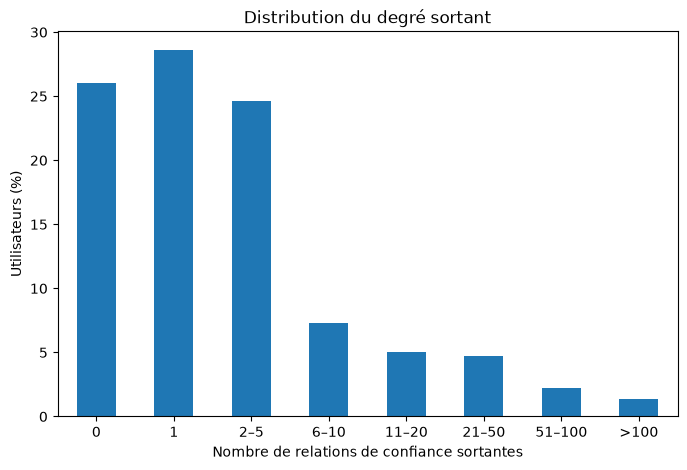

In [88]:
out_degree_classes = pd.cut(
    out_degree,
    bins=[-1, 0, 1, 5, 10, 20, 50, 100, np.inf],
    labels=["0", "1", "2–5", "6–10", "11–20", "21–50", "51–100", ">100"]
)

out_degree_table = (
    out_degree_classes
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
)

out_degree_table.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.xlabel("Nombre de relations de confiance sortantes")
plt.ylabel("Utilisateurs (%)")
plt.title("Distribution du degré sortant")
plt.xticks(rotation=0)
plt.show()

### 7.3 Synthèse

Le réseau social exploitable contient 63 559 utilisateurs et 509 872 relations de confiance. Sa densité est faible (0,0126 %) et les relations sont réparties de manière très hétérogène.

Le degré sortant médian est de 1 : 26,02 % des utilisateurs n'ont aucune relation sortante et 53,25 % en ont entre 1 et 5. L'information sociale disponible varie donc fortement selon les utilisateurs.

## 8. Croisement entre activité de notation et information sociale

L'intérêt d'une approche sociale peut être particulièrement marqué lorsque l'historique d'évaluations d'un utilisateur est limité. Cette partie étudie donc conjointement le nombre d'évaluations et les relations de confiance disponibles pour chaque utilisateur.

In [89]:
user_stats = (
    ratings_per_user
    .to_frame()
    .join(out_degree, how="left")
    .join(in_degree, how="left")
)

user_stats[["out_degree", "in_degree"]] = (
    user_stats[["out_degree", "in_degree"]]
    .fillna(0)
    .astype(int)
)

user_stats.head()

,n_ratings,out_degree,in_degree
user_id,,,
2001,3,0,0
208452,1,0,0
!topher,1,3,0
$p00ky,8,0,6
.475Linebaugh,4,2,1


In [90]:
user_stats.shape

(128962, 3)

In [91]:
user_stats["has_social"] = (
    (user_stats["out_degree"] > 0)
    | (user_stats["in_degree"] > 0)
)

In [92]:
print(
    "Utilisateurs avec information sociale :",
    user_stats["has_social"].sum()
)

Utilisateurs avec information sociale : 63559


In [93]:
user_stats["activity_group"] = pd.cut(
    user_stats["n_ratings"],
    bins=[0, 5, 10, 20, 50, 100, np.inf],
    labels=["1–5", "6–10", "11–20", "21–50", "51–100", ">100"]
)

In [94]:
social_by_activity = (
    user_stats
    .groupby(
        "activity_group",
        observed=True
    )
    .agg(
        utilisateurs=("n_ratings", "size"),
        avec_social=("has_social", "sum"),
        degre_sortant_median=("out_degree", "median")
    )
)

social_by_activity["pct_avec_social"] = (
    100
    * social_by_activity["avec_social"]
    / social_by_activity["utilisateurs"]
)

social_by_activity

,utilisateurs,avec_social,degre_sortant_median,pct_avec_social
activity_group,,,,
1–5,92079,35054,0.0,38.069484
6–10,15096,9792,1.0,64.864865
11–20,10892,8559,2.0,78.580610
21–50,7340,6663,5.0,90.776567
51–100,2167,2109,19.0,97.323489
>100,1388,1382,59.0,99.567723


In [95]:
user_stats["has_outgoing_trust"] = (
    user_stats["out_degree"] > 0
)

In [96]:
outgoing_by_activity = (
    user_stats
    .groupby(
        "activity_group",
        observed=True
    )
    .agg(
        utilisateurs=("n_ratings", "size"),
        avec_confiance_sortante=("has_outgoing_trust", "sum")
    )
)

outgoing_by_activity["pct_confiance_sortante"] = (
    100
    * outgoing_by_activity["avec_confiance_sortante"]
    / outgoing_by_activity["utilisateurs"]
)


In [97]:
activity_social_summary = outgoing_by_activity[
    ["utilisateurs", "avec_confiance_sortante", "pct_confiance_sortante"]
].copy()

activity_social_summary.columns = [
    "utilisateurs",
    "avec_relation_sortante",
    "pct_avec_relation_sortante"
]

activity_social_summary

,utilisateurs,avec_relation_sortante,pct_avec_relation_sortante
activity_group,,,
1–5,92079,23433,25.448799
6–10,15096,7750,51.338103
11–20,10892,7035,64.588689
21–50,7340,5678,77.356948
51–100,2167,1872,86.386710
>100,1388,1254,90.345821


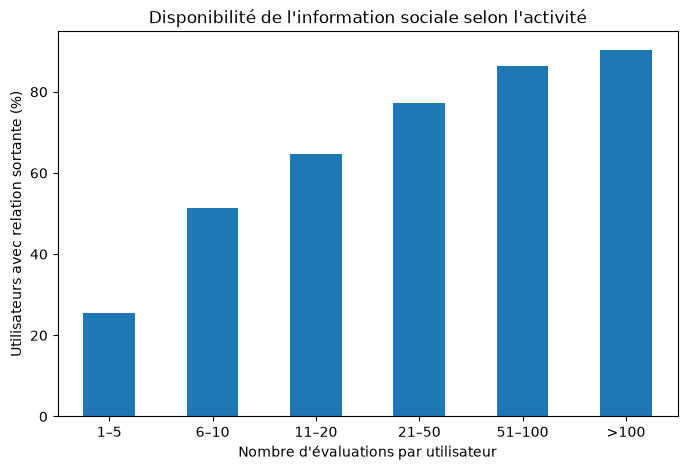

In [98]:
activity_social_summary["pct_avec_relation_sortante"].plot(
    kind="bar",
    figsize=(8, 5)
)

plt.xlabel("Nombre d'évaluations par utilisateur")
plt.ylabel("Utilisateurs avec relation sortante (%)")
plt.title("Disponibilité de l'information sociale selon l'activité")
plt.xticks(rotation=0)
plt.show()

**Conclusion**

La disponibilité de l'information sociale augmente avec l'activité de notation. Parmi les utilisateurs ayant seulement 1 à 5 évaluations, 25,45 % disposent d'au moins une relation de confiance sortante, contre 77,36 % pour ceux ayant 21 à 50 évaluations.

L'information sociale est donc moins souvent disponible pour les utilisateurs ayant le moins d'historique d'évaluations. Toutefois, 23 433 utilisateurs avec seulement 1 à 5 évaluations disposent d'au moins une relation sortante. Cette population permettra d'étudier si l'ajout du contexte social améliore les prédictions lorsque l'historique d'évaluations est limité.

## 9. Synthèse de l'EDA et conséquences pour la modélisation

L'analyse exploratoire met en évidence une matrice utilisateur-item extrêmement creuse, avec une densité de seulement 0,00277 %. Les historiques d'évaluations sont limités :
71,4 % des utilisateurs disposent de 1 à 5 évaluations et 89,68 % des items ont été évalués entre 1 et 5 fois. Ces caractéristiques motivent l'utilisation d'une approche par factorisation matricielle.

Le réseau de confiance synchronisé contient 509 872 relations entre 63 559 utilisateurs disposant d'évaluations. L'information sociale est cependant répartie de manière hétérogène : le degré sortant médian est de 1 et sa
disponibilité augmente avec l'activité de notation.

La modélisation comparera donc une factorisation matricielle classique à une approche intégrant l'information sociale. Les deux méthodes seront évaluées sur les mêmes observations afin de permettre une comparaison équitable.

En complément des performances globales, les résultats seront analysés selon le niveau d'activité des utilisateurs, afin d'étudier l'apport éventuel du contexte social lorsque l'historique d'évaluations est limité.

## 10. Sauvegarde des données préparées


Les données nécessaires à la modélisation sont sauvegardées afin de pouvoir être réutilisées directement dans les notebooks suivants.

In [99]:
RATINGS_FILE = PROCESSED_DIR / "ratings.parquet"
TRUST_FILE = PROCESSED_DIR / "trust_with_ratings.parquet"
USER_STATS_FILE = PROCESSED_DIR / "user_stats.parquet"

ratings.to_parquet(
    RATINGS_FILE,
    index=False
)

trust_with_ratings.to_parquet(
    TRUST_FILE,
    index=False
)

user_stats.reset_index().to_parquet(
    USER_STATS_FILE,
    index=False
)

In [100]:
print(f"Ratings : {ratings.shape}")
print(f"Réseau  : {trust_with_ratings.shape}")
print(f"Users   : {user_stats.shape}")

Ratings : (1238946, 7)
Réseau  : (509872, 2)
Users   : (128962, 6)


In [102]:
# Contrôle
print("Fichiers préparés :")

for file in [
    RATINGS_FILE,
    TRUST_FILE,
    USER_STATS_FILE
]:
    print(
        f"- {file.name} : "
        f"{file.stat().st_size / 1024**2:.2f} Mo"
    )

Fichiers préparés :
- ratings.parquet : 64.11 Mo
- trust_with_ratings.parquet : 2.02 Mo
- user_stats.parquet : 1.56 Mo


In [5]:
ratings.describe()

,rating,review_date
count,1.238946e+06,1238946
mean,3.939129e+00,2003-05-21 11:44:37.732201
min,1.000000e+00,1999-07-05 00:00:00
25%,3.000000e+00,2000-06-22 00:00:00
50%,4.000000e+00,2001-12-03 00:00:00
75%,5.000000e+00,2006-02-26 00:00:00
max,5.000000e+00,2011-05-09 00:00:00
std,1.235728e+00,NaN
